# 01 - Data Understanding

Tahap ini melakukan eksplorasi awal dataset.

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

pd.set_option("display.max_columns", None)

In [ ]:
# Load Dataset
# Ubah nama file sesuai lokasi dataset Anda
df = pd.read_csv("bank_transactions_data_edited - new data(1).csv")

df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [ ]:
# Shape Dataset
print("Jumlah Baris dan Kolom:", df.shape)

Jumlah Baris dan Kolom: (2537, 16)


In [ ]:
# Informasi Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [ ]:
# Statistik Deskriptif
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,2508,2484,TX001748,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountID,2516,495,AC00362,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionAmount,2511.0,NaN,NaN,NaN,297.656468,292.230367,0.26,81.31,211.36,413.105,1919.11
PreviousTransactionDate,2509,2485,2023-10-20 17:53:13,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionType,2507,2,Debit,1942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,2507,43,Fort Worth,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceID,2507,681,D000573,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP Address,2517,591,200.136.146.93,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MerchantID,2514,100,M026,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,2510,3,Branch,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Identifikasi Kolom Numerik dan Kategorikal
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')

Categorical Columns
Index(['TransactionID', 'AccountID', 'PreviousTransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerOccupation', 'TransactionDate'],
      dtype='object')


In [ ]:
# Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean()*100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percent
})

missing_df

,Missing,Percentage
Location,30,1.182499
DeviceID,30,1.182499
TransactionType,30,1.182499
TransactionID,29,1.143082
PreviousTransactionDate,28,1.103666
Channel,27,1.064249
AccountBalance,27,1.064249
TransactionAmount,26,1.024832
TransactionDuration,26,1.024832
TransactionDate,24,0.945999


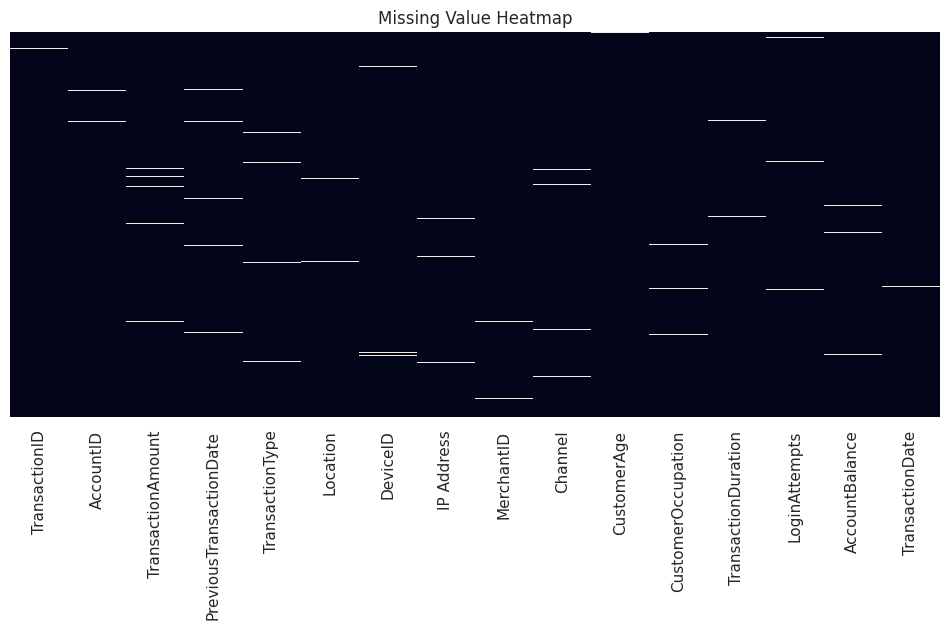

In [ ]:
# Visualisasi Missing Values
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Heatmap")
plt.show()

In [ ]:
# Duplicate Data
duplicate = df.duplicated().sum()
print("Jumlah Duplicate:", duplicate)

Jumlah Duplicate: 21


In [ ]:
# Konversi Format Tanggal
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"], errors="coerce")

print(df[["TransactionDate","PreviousTransactionDate"]].dtypes)

TransactionDate            datetime64[ns]
PreviousTransactionDate    datetime64[ns]
dtype: object


In [ ]:
# Pemeriksaan Nilai Tidak Wajar
print("TransactionAmount negatif :", (df["TransactionAmount"]<0).sum())
print("AccountBalance negatif    :", (df["AccountBalance"]<0).sum())
print("CustomerAge tidak wajar   :", ((df["CustomerAge"]<17)|(df["CustomerAge"]>100)).sum())
print("LoginAttempts negatif     :", (df["LoginAttempts"]<0).sum())
print("TransactionDuration negatif :", (df["TransactionDuration"]<0).sum())

TransactionAmount negatif : 0
AccountBalance negatif    : 0
CustomerAge tidak wajar   : 0
LoginAttempts negatif     : 0
TransactionDuration negatif : 0


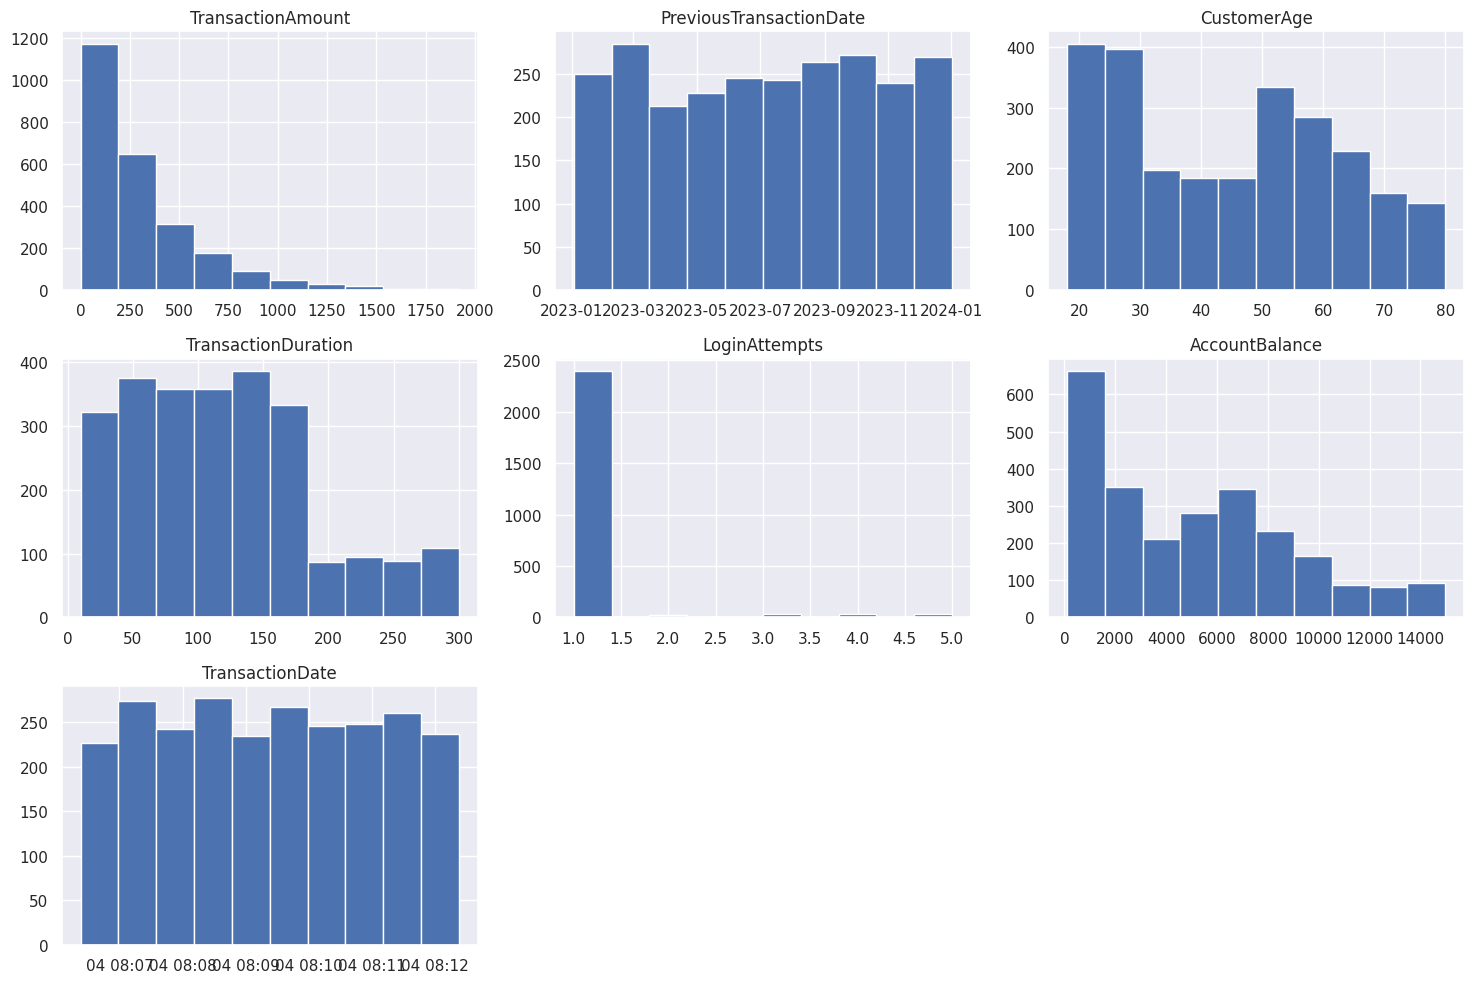

In [ ]:
# Distribusi Variabel Numerik
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

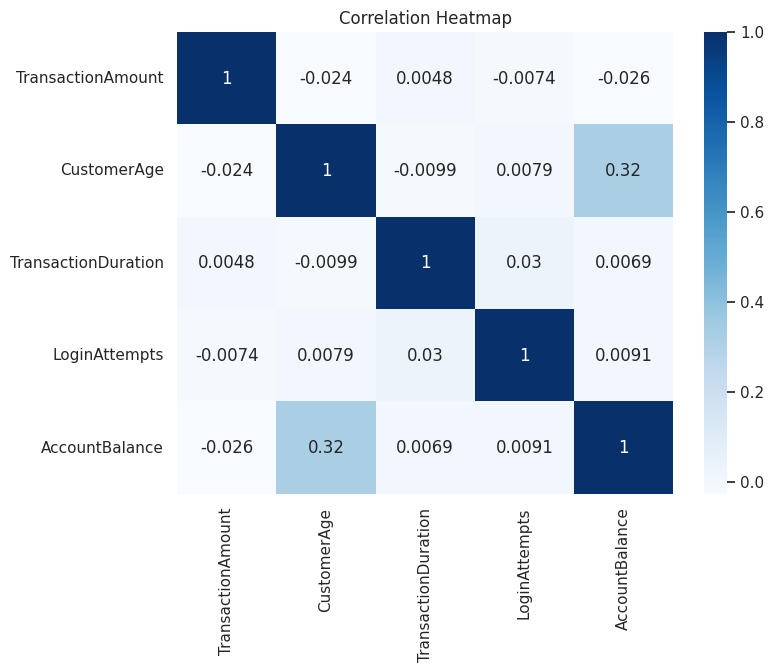

In [ ]:
# Korelasi Antar Variabel Numerik
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=["int64","float64"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()